prepare 

In [16]:
# import the libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from sqlalchemy import create_engine, URL
from dotenv import load_dotenv
import os

load_dotenv()

True

import the data

In [17]:
db_url = URL.create(
    "postgresql+psycopg2",
    username=os.getenv("DB_USERNAME"),
    password=os.getenv("SUPABASE_DB_PASSWORD"),
    host="aws-1-eu-west-1.pooler.supabase.com",
    port=5432,
    database="postgres",
)
engine = create_engine(db_url)

In [18]:
query = """
SELECT
    customer_id,
    MAX(invoice_date) AS last_purchase_date,
    COUNT(DISTINCT invoice_no) AS frequency,
    SUM(total_price) AS monetary
FROM retail_orders
GROUP BY customer_id;
"""

rfm_df = pd.read_sql(query, engine)

rfm_df.head()

,customer_id,last_purchase_date,frequency,monetary
0,12346,2011-01-18 10:01:00,1,77183.60
1,12347,2011-12-07 15:52:00,7,4310.00
2,12348,2011-09-25 13:13:00,4,1797.24
3,12349,2011-11-21 09:51:00,1,1757.55
4,12350,2011-02-02 16:01:00,1,334.40


In [19]:
# calculate recency

reference_date = rfm_df['last_purchase_date'].max() + pd.Timedelta(days=1)
rfm_df['recency'] = (reference_date - rfm_df['last_purchase_date']).dt.days
rfm_df = rfm_df.drop(columns=['last_purchase_date'])

rfm_df.info()
rfm_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  4338 non-null   int64  
 1   frequency    4338 non-null   int64  
 2   monetary     4338 non-null   float64
 3   recency      4338 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 135.7 KB


,customer_id,frequency,monetary,recency
0,12346,1,77183.60,326
1,12347,7,4310.00,2
2,12348,4,1797.24,75
3,12349,1,1757.55,19
4,12350,1,334.40,310


Feature matrix:

In [20]:
X = rfm_df[['recency', 'frequency', 'monetary']]
print("X shape:", X.shape)
X.head()

X shape: (4338, 3)


,recency,frequency,monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


Fine-tune hyperparameters for the number of clusters

In [21]:
n_clusters = range(2, 13)
inertia_errors = []
silhouette_scores = []

for k in n_clusters:
    model = make_pipeline(
        StandardScaler(), KMeans(n_clusters=k, random_state=42)
    )
    model.fit(X)
    inertia_errors.append(model.named_steps["kmeans"].inertia_)
    silhouette_scores.append(silhouette_score(X, model.named_steps["kmeans"].labels_))

print("Inertia:", inertia_errors[:5])
print()
print("Silhouette Scores:", silhouette_scores[:5])

Inertia: [9356.741301403197, 5444.880985060552, 4599.424413823731, 3118.162848055752, 2531.8234308078477]

Silhouette Scores: [-0.18168297837688765, -0.08872764758523398, -0.10654629950446812, -0.04773447386839141, -0.007729826732770886]


visualize the clusters vs inertia & silhouette scores

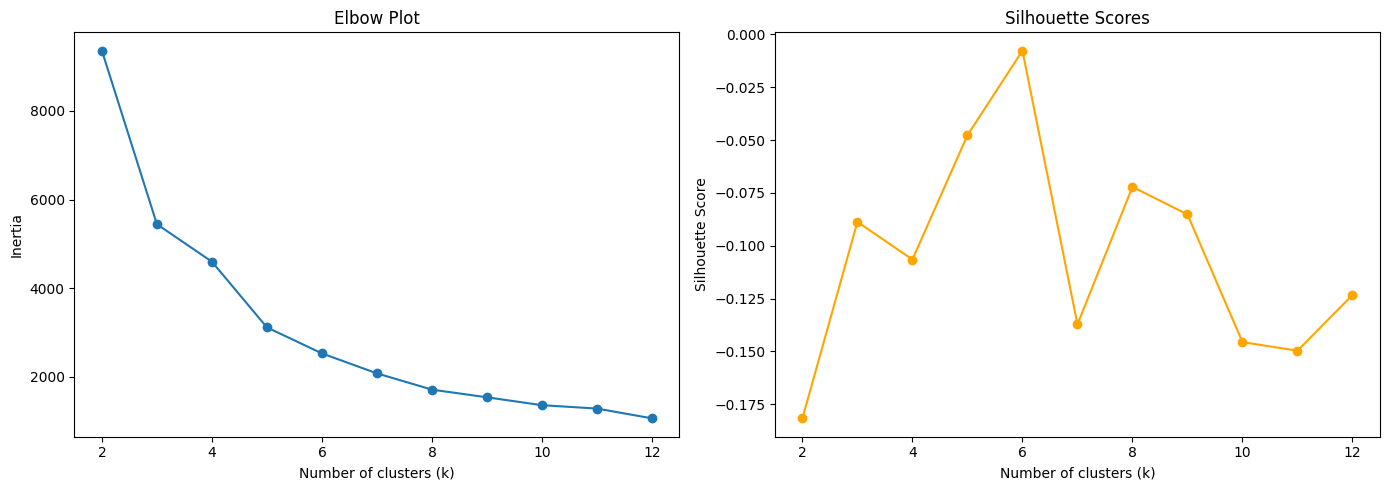

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_clusters, inertia_errors, marker='o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot')

axes[1].plot(n_clusters, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores')

plt.tight_layout()
plt.show()

train the final model

In [23]:
# Fit final model with k=6
final_model = make_pipeline(
    StandardScaler(), KMeans(n_clusters=6, random_state=42)
)
final_model.fit(X)
rfm_df['cluster'] = final_model.named_steps['kmeans'].labels_

# Profile the clusters
rfm_df.groupby('cluster')[['recency', 'frequency', 'monetary']].mean()

,recency,frequency,monetary
cluster,,,
0,45.141638,3.311604,1206.599652
1,248.938621,1.550519,516.818659
2,1.857143,128.714286,51420.158571
3,27.529412,38.764706,64484.415294
4,3.000000,45.250000,225681.652500
5,15.697819,16.965732,7592.668785


plot the clusters

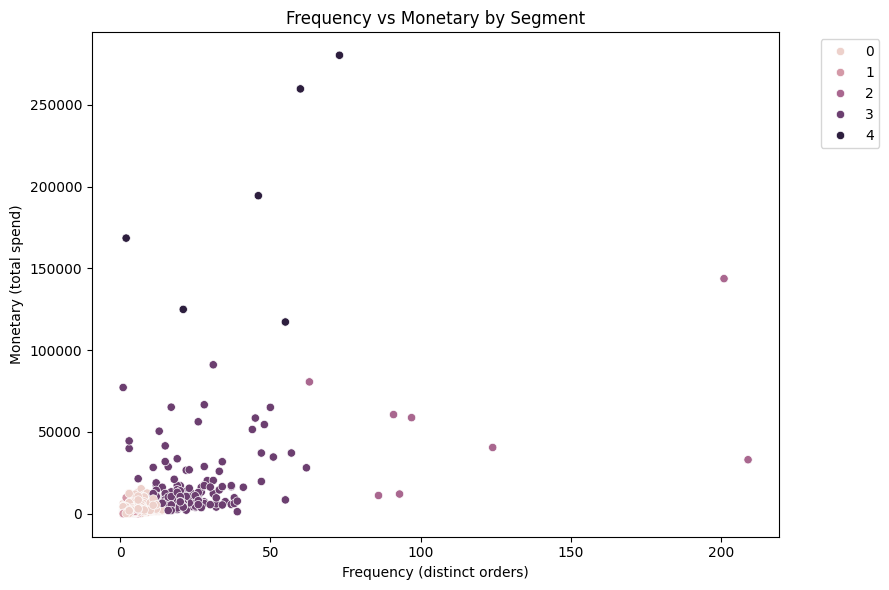

In [ ]:
# 2. Frequency vs Monetary, colored by cluster
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm_df,
    x='frequency',
    y='monetary',
    hue='cluster'
)
plt.title('Frequency vs Monetary by cluster')
plt.xlabel('Frequency (distinct orders)')
plt.ylabel('Monetary (total spend)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

RFM distributions by clusters

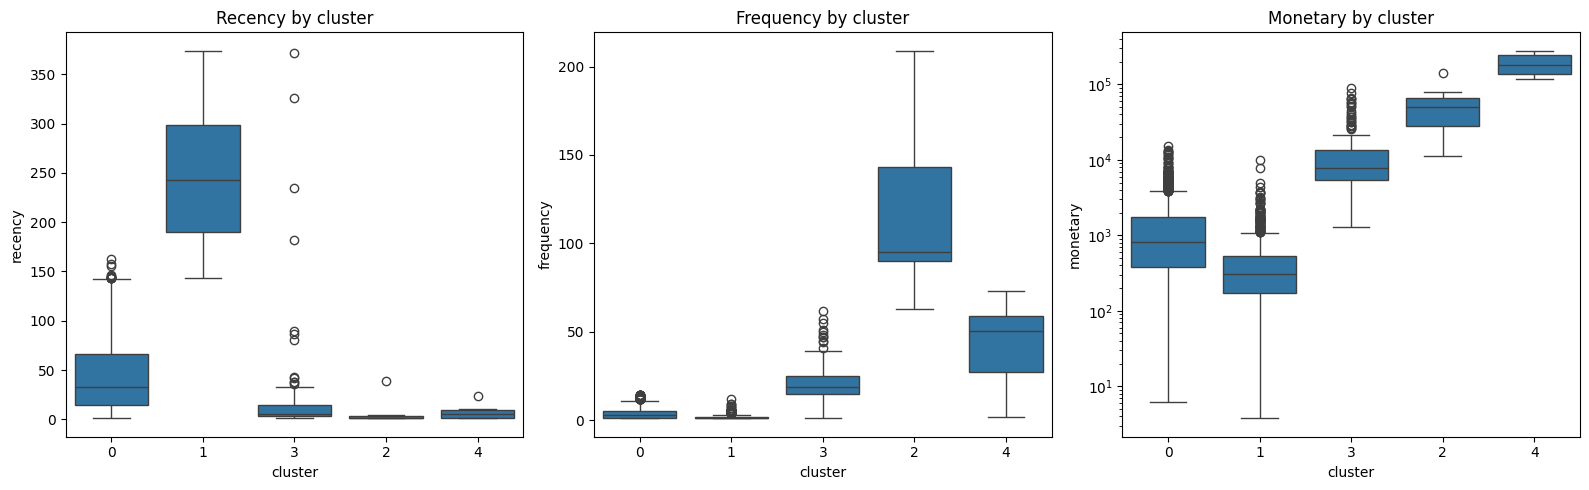

In [33]:
# 3. R, F, M distributions by cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cluster_order = rfm_df['cluster'].value_counts().index


sns.boxplot(data=rfm_df, x='cluster', y='recency', ax=axes[0], order=cluster_order)
axes[0].set_title('Recency by cluster')
axes[0].tick_params(axis='x')

sns.boxplot(data=rfm_df, x='cluster', y='frequency', ax=axes[1], order=cluster_order)
axes[1].set_title('Frequency by cluster')
axes[1].tick_params(axis='x')

sns.boxplot(data=rfm_df, x='cluster', y='monetary', ax=axes[2], order=cluster_order)
axes[2].set_title('Monetary by cluster')
axes[2].tick_params(axis='x')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()